## DATA VISUALIZATION

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('Superstore.csv', encoding='latin-1')

In [3]:
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [5]:
import os 
os.makedirs('dashboards', exist_ok=True)

### Matplotlib Plots

#### Line chart - Sales trend over time

C:\Users\Igrit\AppData\Local\Temp\ipykernel_9356\2787898215.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()


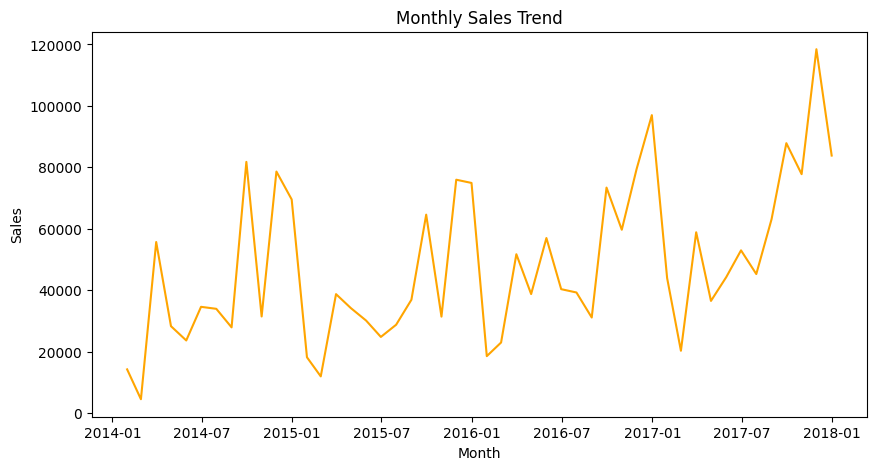

In [6]:
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, color='orange')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("dashboards/sales_trend.png")
plt.show()

#### Bar chart - Sales by Category

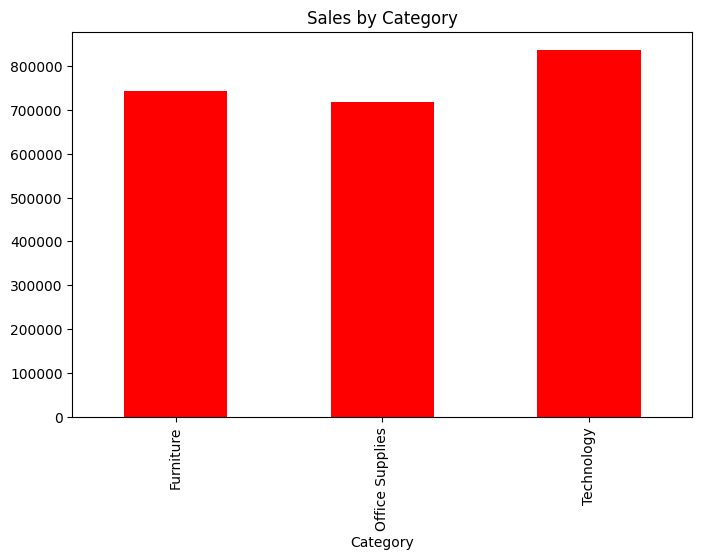

In [7]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().plot(kind='bar', color='red')
plt.title("Sales by Category")
plt.savefig("dashboards/sales_by_category.png")
plt.show()

#### Scatter plot - Sales vs Profit

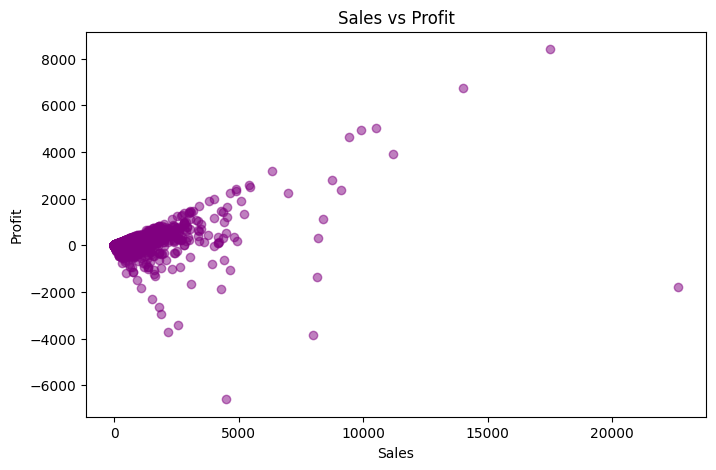

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'], alpha=0.5, color='purple')
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.savefig("dashboards/sales_vs_profit.png")
plt.show()

#### Histogram - Sales distribution

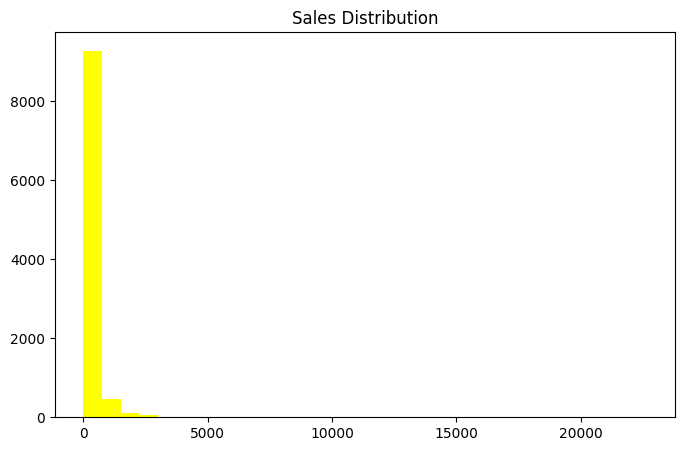

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30, color='yellow')
plt.title("Sales Distribution")
plt.savefig("dashboards/sales_distribution.png")
plt.show()


### SEABORN PLOTS 

#### Heatmap - Correlation matrix

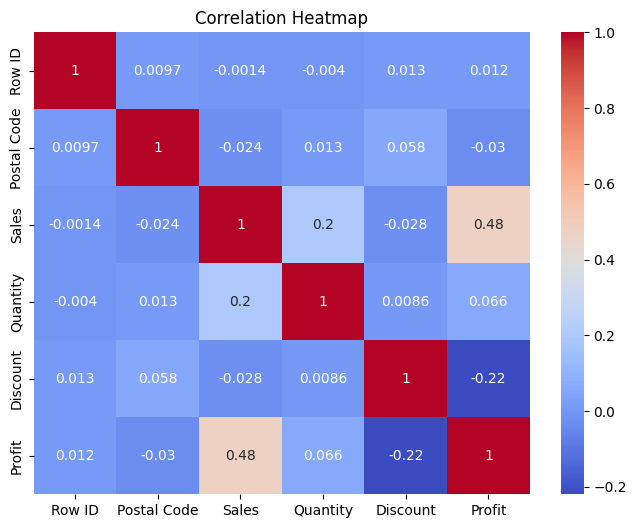

In [10]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("dashboards/correlation_heatmap.png")
plt.show()

#### Pairplot

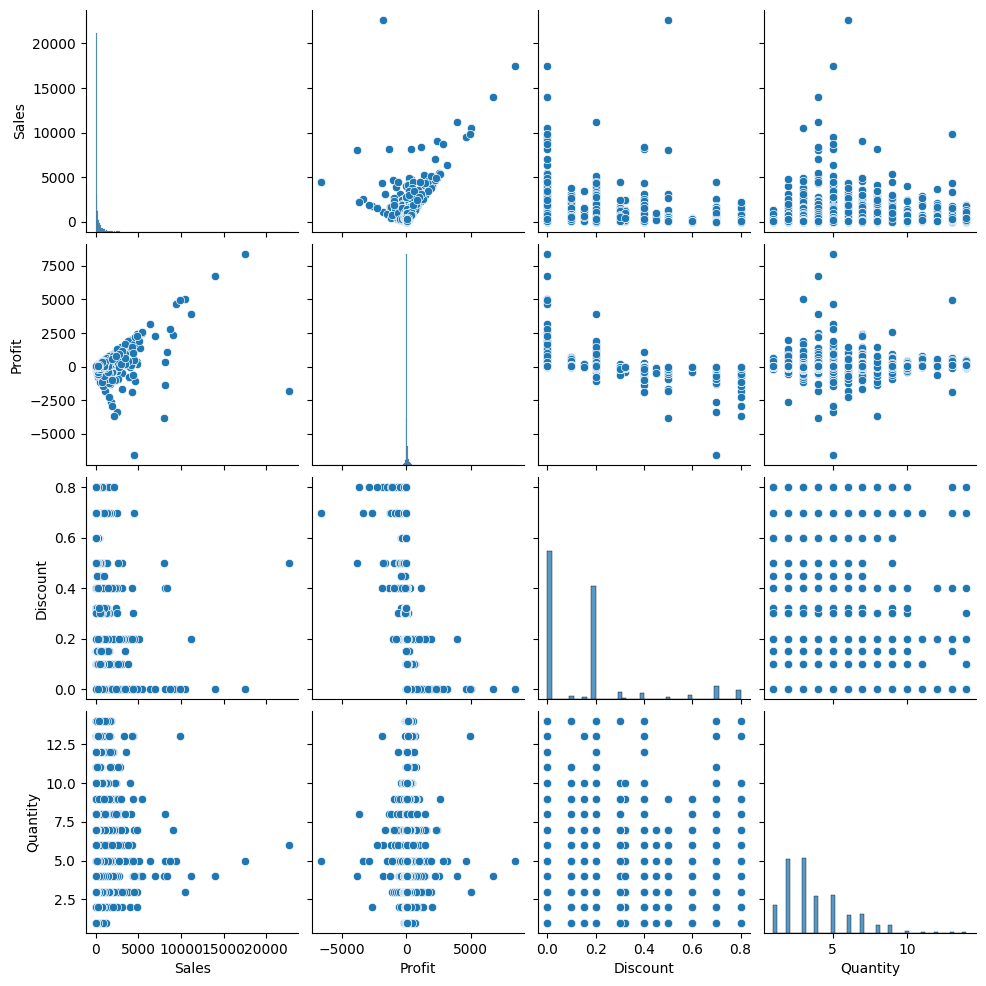

In [11]:
sns.pairplot(df[['Sales', 'Profit', 'Discount', 'Quantity']])
plt.savefig("dashboards/pairplot.png")
plt.show()

#### Boxenplot - Profit by Category

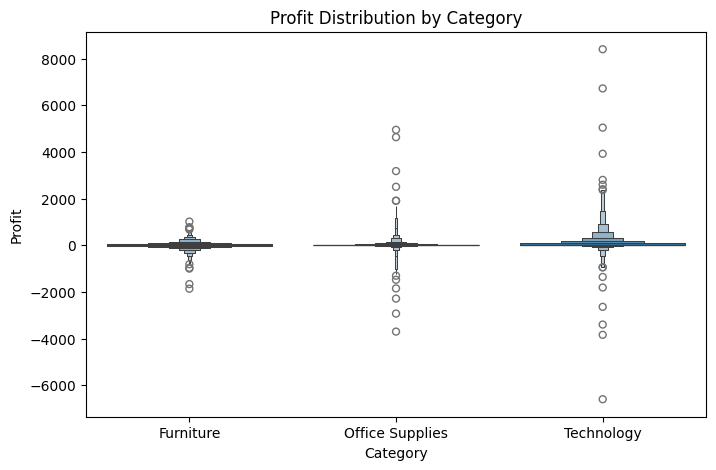

In [12]:
plt.figure(figsize=(8,5))
sns.boxenplot(x='Category', y='Profit', data=df)
plt.title("Profit Distribution by Category")
plt.savefig("dashboards/profit_boxenplot.png")
plt.show()

###  PLOTLY INTERACTIVE PLOTS

#### Interactive sales trend

In [13]:
fig1 = px.line(monthly_sales.reset_index(), x='Order Date', y='Sales', title="Interactive Monthly Sales Trend")
fig1.write_html("dashboards/interactive_sales_trend.html")
fig1.show()

#### Interactive sales by sub-category

In [14]:
sub_cat_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
fig2 = px.bar(sub_cat_sales, x='Sub-Category', y='Sales', title="Sales by Sub-Category", color='Sales')
fig2.write_html("dashboards/interactive_subcategory_sales.html")
fig2.show()

#### Interactive region-wise sales (treemap)

In [15]:
fig3 = px.treemap(df, path=['Region', 'Category', 'Sub-Category'], values='Sales',
                   title="Sales Breakdown: Region > Category > Sub-Category")
fig3.write_html("dashboards/interactive_treemap.html")
fig3.show()